# MF Teanaway Tutorial Qggl Mean Spline Fit Analysis
### 100m Transect Interval & 1m Transect Station Interval
---
### Author:
Matt Helstab  
Aquatic Restoration Hydro-Geo-Ecologist  
Enterprise Aquatic Restoration Team   
USDA - Forest Service - WO 

---
### Generalized Workflow with Naming Conventions

1. **Data Acquisition**
   - `transect_stations`: Name of the transect station layer (string)
   - `fc_name`: Feature class name for transect stations (string)
   - `fc_gdb`: Path to the geodatabase containing the feature class (string)
   - `fc_path`: File system path to the feature class location (string)

2. **Raw Data Prep**
   - `df_raw`: Raw DataFrame, identical to the feature class attribute table

3. **Data Cleaning**
   - `df_vf`: Cleaned DataFrame of all transects and stations
 
4. **Filtering**
   - `df_vf_<filtered>`: Filtered DataFrame of transects/stations by condition (e.g., elevation, location, surface type)

5. **Statistics**
   - `ds_vf_<filtered>`: Descriptive statistics DataFrame for filtered transect elevations

6. **Modeling**
   - `fit_vf_<filtered>_model`: Univariate spline model object
   - `fit_vf_<filtered>_table`: DataFrame of spline fit results

7. **Visualization**
   - `fit_vf_<filtered_figs`: Figures generated from spline fits

8. **Surface Modeling (TIN)**
   - `tin_fit_vf_<filtered>_<fit>`: Triangulated Irregular Network (TIN) created from filtered transect data

9. **Raster Conversion**
   - `tin_raster_fit_vf_<filtered>_<fit>`: Raster dataset generated from TIN surface

10. **Relative Elevation Model (REM)**
    - `tin_rem_fit_vf_<filtered>_<fit>`: REM raster derived from TIN-to-Raster conversion, showing relative elevation

---
<!-- Info style -->
<div style="border:2px solid #2196F3; padding:10px; background-color:#E3F2FD;">
    ℹ️ <b>Note:</b> Replace <code>&lt;filtered&gt;</code> with your specific condition (e.g., `idw_less8m`, `surface_fp`, etc.).
    <br>Step 6 will append model input paramters to <code>&lt;fit&gt;</code>. 
</div>
<br>
<div style="border:2px solid #2196F3; padding:10px; background-color:#E3F2FD;">
    ℹ️ <b>Note:</b>Step 6 will append string of model input paramters to <code>&lt;fit&gt;</code>. 
</div>


---
### References

- [Python.org](https://www.python.org/about/gettingstarted/) — General programming language, getting started  
- [Notebook Basics](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Notebook%20Basics.html) — Interactive coding and documentation environment  
- [Markdown Guide](https://www.markdownguide.org/basic-syntax/) — Lightweight markup language for documentation  
- [NumPy Docs](https://numpy.org/doc/stable/user/absolute_beginners.html) — Numerical computing, arrays, math functions  
- [Pandas](https://pandas.pydata.org/) — Data manipulation and analysis  
- [MatPlotLib Pyplot](https://matplotlib.org/stable/tutorials/pyplot.html) — Visualization library for charts and plots  
- [Seaborn Intro](https://seaborn.pydata.org/tutorial/introduction.html) — Statistical data visualization  
- [SciPy Docs](https://docs.scipy.org/doc/scipy/) — Scientific computing, stats, optimization  
- [ArcPy Tools](https://pro.arcgis.com/en/pro-app/latest/arcpy/get-started/what-is-arcpy-.htm) — GIS automation and geoprocessing in ArcGIS  

# Import Python Packages

In [7]:
# Standard library
import os
import datetime

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import interpolate, stats

# Local / specialized libraries
import arcpy

%matplotlib inline

# Import Custom Python Functions 


- **read_layer** – Reads an ArcPy layer into a Pandas DataFrame and returns metadata.  
- **long_plot** – Plots a longitudinal profile with elevation statistics (max, mean, min).  
- **transect_plot** – Plots a single transect profile with mean, ±1 SD, and optional filtered stats.  
- **describe_stats** – Computes grouped descriptive statistics and interquartile range (IQR).  
- **boxplot** – Creates a boxplot for a numeric field with summary stats.  
- **histplot** – Plots a histogram with KDE and highlights mean ±1 SD.  
- **histplot_compare** – Compares histograms and stats for full vs. filtered datasets.  
- **spline_fit** – Fits a univariate spline to profile data and generates diagnostic plots.  
- **csv_join** – Saves a DataFrame to CSV and optionally joins it to a feature class in ArcGIS.  
- **long_plot_compare** – Compares longitudinal profiles for full vs. filtered datasets.  
- **create_rem_from_tin** – Builds a Relative Elevation Model (REM) from TIN and LiDAR DEM in ArcGIS.  


<!-- Warning style -->
<div style="border:2px solid #FF9800; padding:10px; background-color:#FFF3E0;">
    ⚠️ <b>Caution:</b> User needs to update <code>pf_path</code> below with local path to <i>PythonFuncs.py</i>
</div>

In [8]:
pf_path = r"T:\FS\BusOps\EnterpriseProgram\Program\AquaticRestoration\Python\Scripts"
sys.path.append(pf_path)
import PythonFuncs_03DEC2025 as pf


# Identify Transect Station Feature Class Data  
<br>
<!-- Info style -->
<div style="border:2px solid #2196F3; padding:10px; background-color:#E3F2FD;">
ℹ️ <b>Note:</b> Please replace <i>Layer Name</i> inside the quotations in the next code block with the name of your own layer file.
</div>


In [9]:
transect_stations = "MFT_VCL_GTAL_100m_GPAL_1m"

### Function: `read_layer`

This function reads an ArcPy layer into a Pandas DataFrame and returns metadata.

**Parameters:**
- `layer_name` *(str)*: Path to a Feature Class, Shapefile, or Layer Name in ArcGIS Pro Contents   
- `set_workspace` *(bool, optional)*: If `True`, sets the ArcPy environment workspace to the layer's GDB. Default is `True`.


**Returns:**
A tuple with four elements:
- `fc_name` *(str)*: feature class name  
- `fc_gdb` *(str)*: feature class GDB path
- `fc_path` *(str)*: feature class parent folder path  
- `df_raw` *(pd.DataFrame)*: Pandas DataFrame containing the feature class attributes

**Example:**
```python
fc_name, fc_gdb, fc_path, df_raw = ReadLayer(
    layer_name= transect_stations,
    set_workspace= True)


In [10]:
fc_name, fc_gdb, fc_path, df_raw = pf.read_layer(transect_stations)

fc_name = MFT_VCL_GTAL_100m_GPAL_1m
fc_gdb = T:\FS\BusOps\EnterpriseProgram\Program\AquaticRestoration\Projects\Washington\Teanaway\Teanaway_Tutorial_Helstab\Teanaway_Tutorial_Helstab.gdb
fc_path = T:\FS\BusOps\EnterpriseProgram\Program\AquaticRestoration\Projects\Washington\Teanaway\Teanaway_Tutorial_Helstab


# Inspect and Clean DataFrame

In [11]:
df_raw.head() ### Inspect your Data Frame

,OBJECTID,Shape,Transect_Station_Length,Transect_Station_ID,VCL_Station_Length,VCL_Station_Sequence,Surface_Type,DEM_Bathy_2023,IDW_REM_MFT_Flowline_GPAL_1m_Sandstone,Fit_VF_Less8m_min_poly3_s5,Join_Count,Fit_VF_Less8m_min_poly3_s5_RE,Fit_FP2T1_mean_poly3_s2
0,1,"(468667.48640000075, 215847.85770000145)",0.0,1,2300.0,2300,None,735.188110,11.342000,723.707264,0,11.480846,725.533508
1,2,"(468668.2877999991, 215848.45589999855)",1.0,2,2300.0,2300,None,735.113647,11.289610,723.707264,0,11.406383,725.533508
2,3,"(468669.08910000324, 215849.05409999937)",2.0,3,2300.0,2300,None,735.031616,11.219985,723.707264,0,11.324352,725.533508
3,4,"(468669.8905000016, 215849.6521999985)",3.0,4,2300.0,2300,None,734.949280,11.136172,723.707264,0,11.242016,725.533508
4,5,"(468670.6917999983, 215850.25039999932)",4.0,5,2300.0,2300,None,734.722168,10.985135,723.707264,0,11.014904,725.533508


## Print Column Names

In [12]:
for col in df_raw.columns:
    print(col)

OBJECTID
Shape
Transect_Station_Length
Transect_Station_ID
VCL_Station_Length
VCL_Station_Sequence
Surface_Type
DEM_Bathy_2023
IDW_REM_MFT_Flowline_GPAL_1m_Sandstone
Fit_VF_Less8m_min_poly3_s5
Join_Count
Fit_VF_Less8m_min_poly3_s5_RE
Fit_FP2T1_mean_poly3_s2


## Identify Field Names and Assign Generic Variables for Analysis
<br>
<!-- Info style -->
<div style="border:2px solid #2196F3; padding:10px; background-color:#E3F2FD;">
ℹ️ <b>Note:</b>  Update <i>names</i> inside the quotations as needed to match DataFrame column.
</div>

In [13]:
x = "VCL_Station_Sequence" ### Valley centerline id column
y = "Transect_Station_ID" ### Transect station id column
z = "DEM_Bathy_2023" ### Elevation value column
idw = "IDW_REM_MFT_Flowline_GPAL_1m_Sandstone" ### IDW-REM column
s = "Surface_Type" ### Surface type column

## Create Cleaned and Sorted DataFrame

In [14]:
df_vf = df_raw[[x, y, s, z, idw]].sort_values([x,y])

In [15]:
df_vf

,VCL_Station_Sequence,Transect_Station_ID,Surface_Type,DEM_Bathy_2023,IDW_REM_MFT_Flowline_GPAL_1m_Sandstone
7666,0,1,None,689.133545,1.184922
7667,0,2,None,689.217773,1.285391
7668,0,3,None,689.300598,1.396089
7669,0,4,None,689.326904,1.436027
7670,0,5,None,689.334167,1.450857
...,...,...,...,...,...
22731,7700,47,None,831.834412,17.601597
22732,7700,48,None,832.845093,18.994923
22733,7700,49,None,834.132385,20.607889
22734,7700,50,None,835.481140,21.758926


# Use Conditional Formatting to Filter DataFrame

### Generic Pandas Conditional Filtering Examples


```python
# Values less than or equal to 8

df_filtered = df[df["col1"] <= 8]

# Values where col1 <= 8 AND col2 == "A"
df_filtered = df[(df["col1"] <= 8) & (df["col2"] == "A")]

# Values where col1 <= 8 OR col2 == "A"
df_filtered = df[(df["col1"] <= 8) | (df["col2"] == "A")]

# Values where col1 is NOT equal to 8
df_filtered = df[df["col1"] != 8]

# Values where col1 is between 5 and 10 (inclusive)
df_filtered = df[df["col1"].between(5, 10)]


## Create Filtered DataFrame Where IDW-REM Values ≤ 8 m

In [16]:
df_vf_less8m = df_vf[df_vf['IDW_REM_MFT_Flowline_GPAL_1m_Sandstone'] <= 8]

In [17]:
df_vf_less8m

,VCL_Station_Sequence,Transect_Station_ID,Surface_Type,DEM_Bathy_2023,IDW_REM_MFT_Flowline_GPAL_1m_Sandstone
7666,0,1,None,689.133545,1.184922
7667,0,2,None,689.217773,1.285391
7668,0,3,None,689.300598,1.396089
7669,0,4,None,689.326904,1.436027
7670,0,5,None,689.334167,1.450857
...,...,...,...,...,...
22720,7700,36,None,819.418152,5.564698
22721,7700,37,None,820.151611,5.843194
22722,7700,38,None,820.271606,6.030108
22723,7700,39,None,820.433899,6.396266


## Create Filtered DataFrame Where Surface_Type Equals FP or T!

In [18]:
df_vf_less8m['Surface_Type'].unique()

array([None, 'T1', 'FP', 'T2', 'T3', 'T4', 'T5', 'GB'], dtype=object)

In [19]:
df_vf_fp2t1 = df_vf_less8m[(df_vf_less8m['Surface_Type'] == "FP") | (df_vf_less8m['Surface_Type'] == "T1")]

In [20]:
df_vf_fp2t1

,VCL_Station_Sequence,Transect_Station_ID,Surface_Type,DEM_Bathy_2023,IDW_REM_MFT_Flowline_GPAL_1m_Sandstone
7448,100,187,T1,688.994263,1.702332
7449,100,188,T1,688.844666,1.548162
7450,100,189,FP,688.692688,1.410194
7451,100,190,FP,688.609009,1.299494
7452,100,191,FP,688.674622,1.293798
...,...,...,...,...,...
20905,7300,37,T1,809.482117,1.916924
20906,7300,38,T1,809.944031,2.370062
20907,7300,39,T1,810.162476,2.647681
20908,7300,40,T1,810.206055,2.742823


# Plot Longitudinal Profile of Transect Elevation Statistics

### Function: `long_plot`

This function generates a longitudinal profile along the valley centerline, showing summary statistics (min, mean ± std, max) of transect elevation data.
>Assumes metric units

**Parameters:**
- `df` (pd.DataFrame): Input data
- `vcl_stations` (str): Column name for station positions
- `elevation` (str): Column name for elevation values
- `interval` (int, optional): Segment length for subplots
- `aspect` (float or str, optional): Aspect ratio for plots
- `title` (str, optional): Plot title

**Returns:**
- `(fig, ax)`: Matplotlib figure and axis

**Example:**
```python
long_plot(
    df=df_vf,
    vcl_stations=x,
    elevaiton=y,
    interval=None
    aspect=None,
    title="Longitudinal Transect Elevaton Profile" )
```

<br>
<!-- Info style -->
<div style="border:2px solid #2196F3; padding:10px; background-color:#E3F2FD;">
ℹ️ <b>Note:</b> To save the figure, remove the leading <code>#</code> from the code line and replace <code>&lt;plot_name&gt;</code> with a unique name. For example:<br>
    <code>[0].savefig(fc_path + r'\myplot_lp.png')</code>
</div>

All Transect Stations
Profile Elevation Change = 149.24 meters
Profile Length = 7700.00 meters
Generic Slope (Rise/Run) = 1.938 %
--------------------------------------------------
Transect Stations (IDW <= 8m)
Profile Elevation Change = 135.58 meters
Profile Length = 7700.00 meters
Generic Slope (Rise/Run) = 1.761 %
--------------------------------------------------
Transect Stations (FP to T1 Surfaces)
Profile Elevation Change = 121.96 meters
Profile Length = 7200.00 meters
Generic Slope (Rise/Run) = 1.694 %
--------------------------------------------------


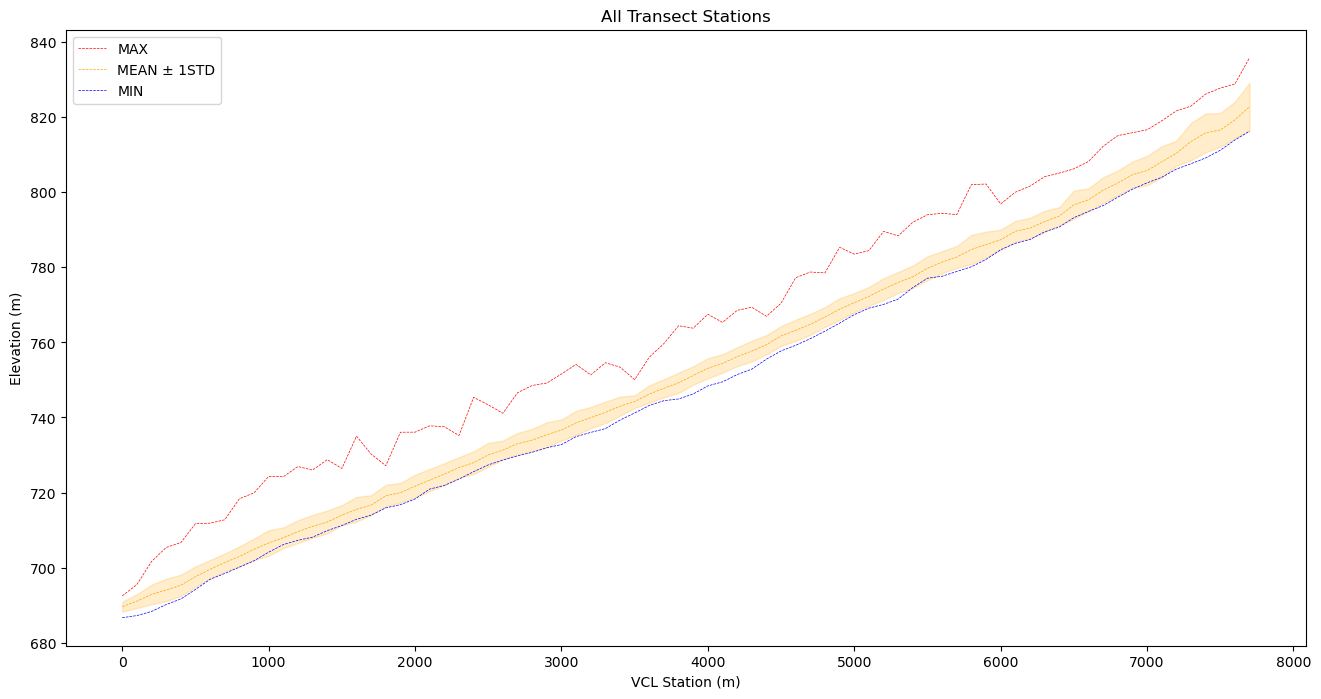

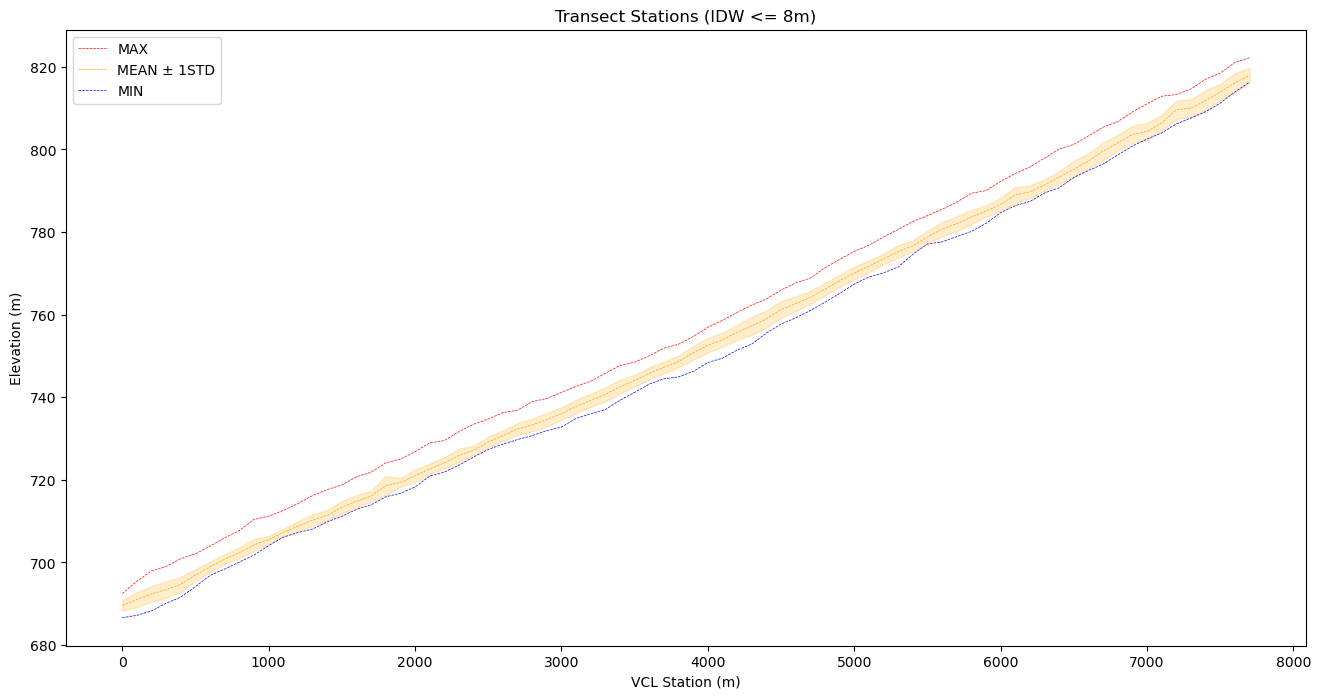

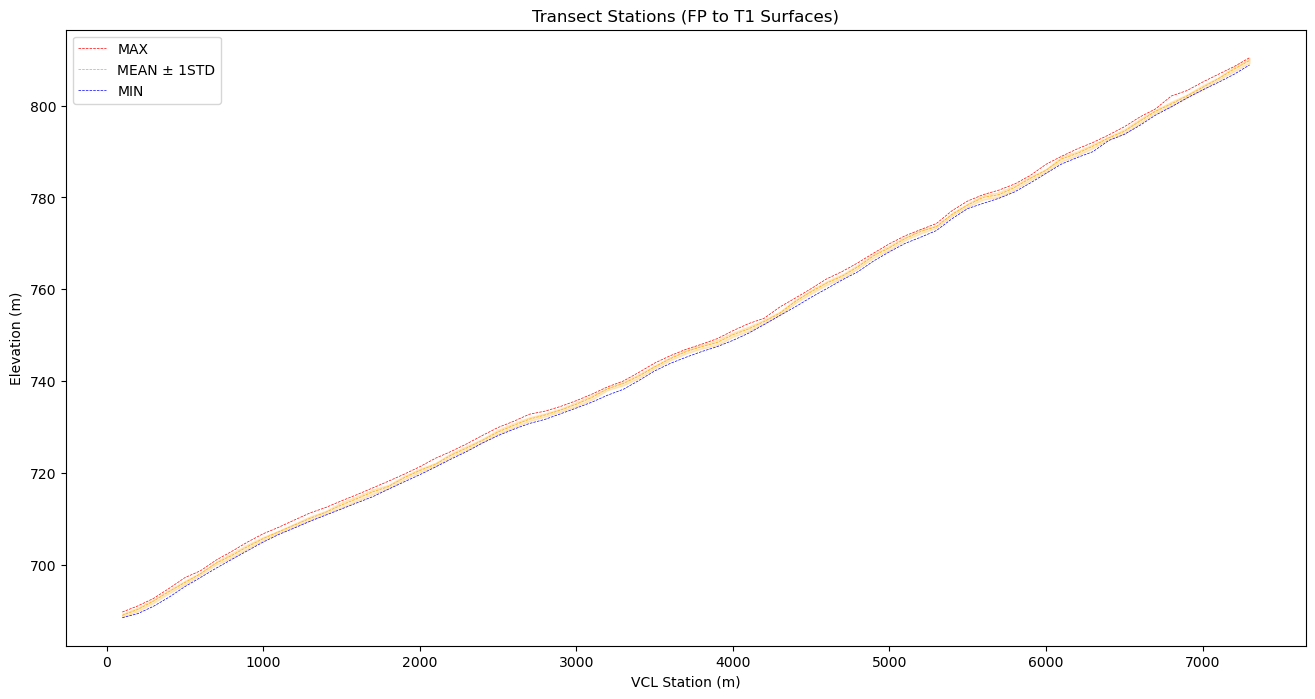

In [21]:
df_vf_lp = pf.long_plot(df_vf, x, z, interval=None, aspect=None, title="All Transect Stations")#[0].savefig(fc_path + r'\<plot_name>_lp.png')
df_vf_less8m_lp = pf.long_plot(df_vf_less8m, x, z, interval=None, aspect=None, title="Transect Stations (IDW <= 8m)")#[0].savefig(fc_path + r'\<plot_name>_lp.png')
df_vf_fp2t1_lp = pf.long_plot(df_vf_fp2t1, x, z, interval=None, aspect=None, title="Transect Stations (FP to T1 Surfaces)")#[0].savefig(fc_path + r'\<plot_name>_lp.png')

## Compare Longitudinal Profile Plots (All vs Filtered)

### Function: `long_plot_compare`

This function generates line plots of transect elevation statistics across a longitudinal profile.  
It can either plot the entire dataset or split the profile into interval segments for comparison.

**Parameters:**
- `df` *(pd.DataFrame)*: Pandas DataFrame containing the full transect data.
- `df_filtered` *(pd.DataFrame)*: Filtered DataFrame (e.g., subset of stations).
- `vcl_stations` *(str)*: Column name for centerline station values (independent variable).
- `elevation` *(str)*: Column name for elevation values (dependent variable).
- `interval` *(int or None, default=None)*: Interval size for splitting the profile.  
  - If `None`, plots the entire dataset as one figure.  
  - If an integer, plots each interval slice separately.

**Returns:**
- `figs` *(list of matplotlib.figure.Figure)*: List of Matplotlib figures generated for each plot.

**Example:**
```python
# Plot entire dataset
figs = long_plot_compare(
    df=df_vf,
    df_filtered=df_vf_less8m,
    vcl_stations="Station",
    elevation="Elevation",
    interval=None
)

# Plot dataset in 100 m intervals
figs = long_plot_compare(
    df=df_vf,
    df_filtered=df_vf_less8m,
    vcl_stations="Station",
    elevation="Elevation",
    interval=100
)


[<Figure size 1500x800 with 1 Axes>,
 <Figure size 1500x800 with 1 Axes>,
 <Figure size 1500x800 with 1 Axes>,
 <Figure size 1500x800 with 1 Axes>,
 <Figure size 1500x800 with 1 Axes>,
 <Figure size 1500x800 with 1 Axes>,
 <Figure size 1500x800 with 1 Axes>,
 <Figure size 1500x800 with 1 Axes>]

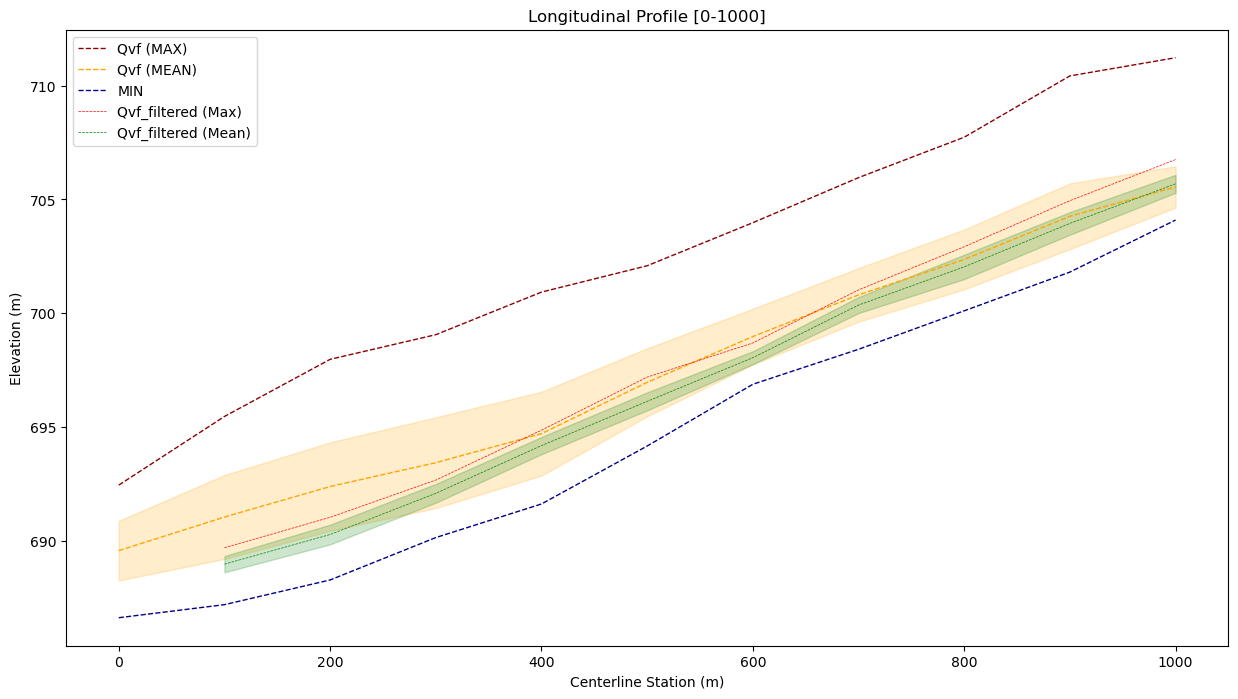

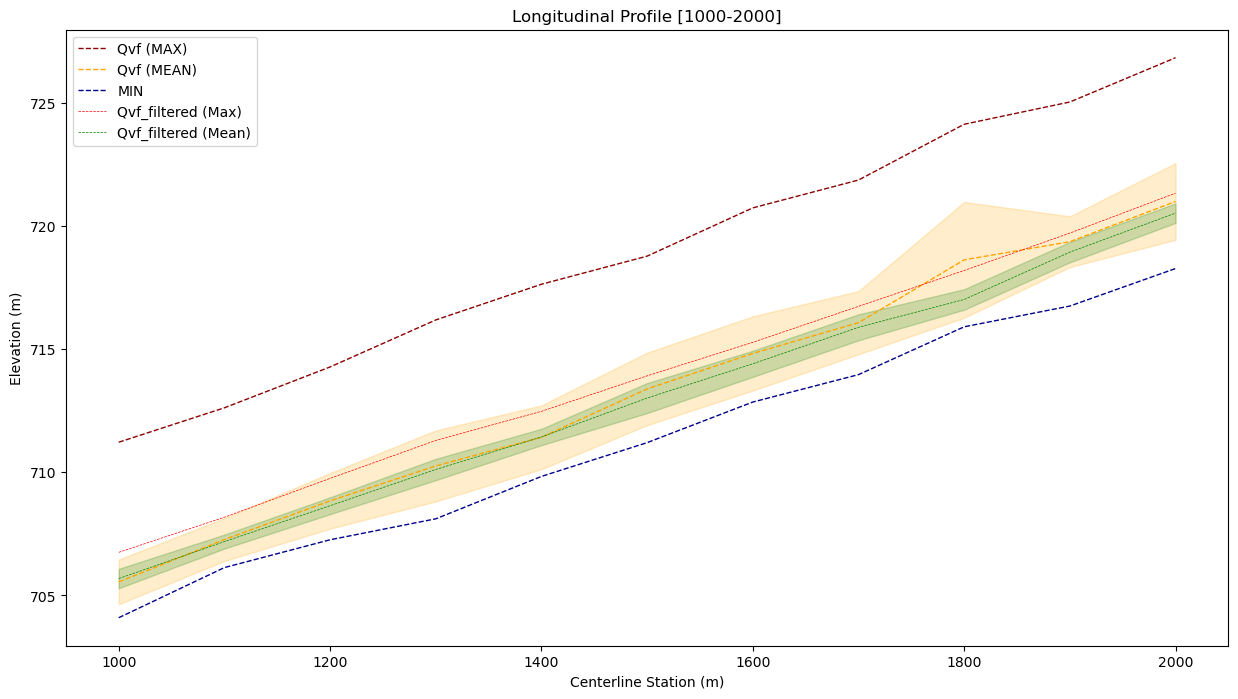

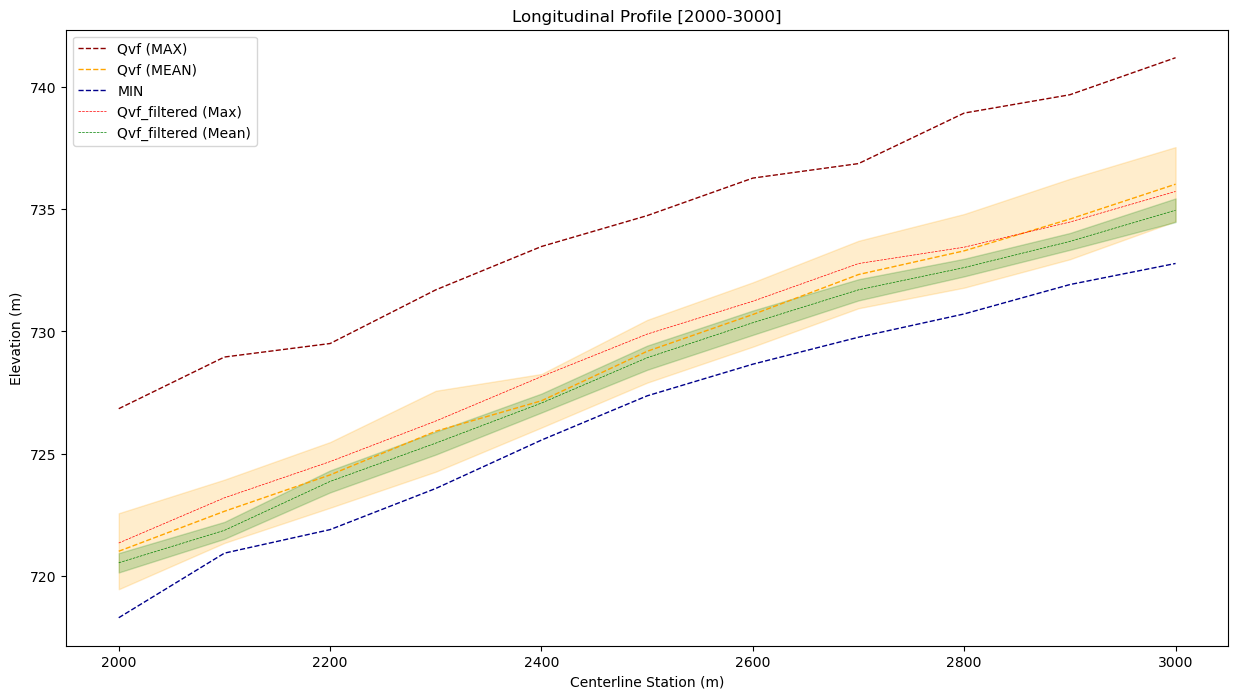

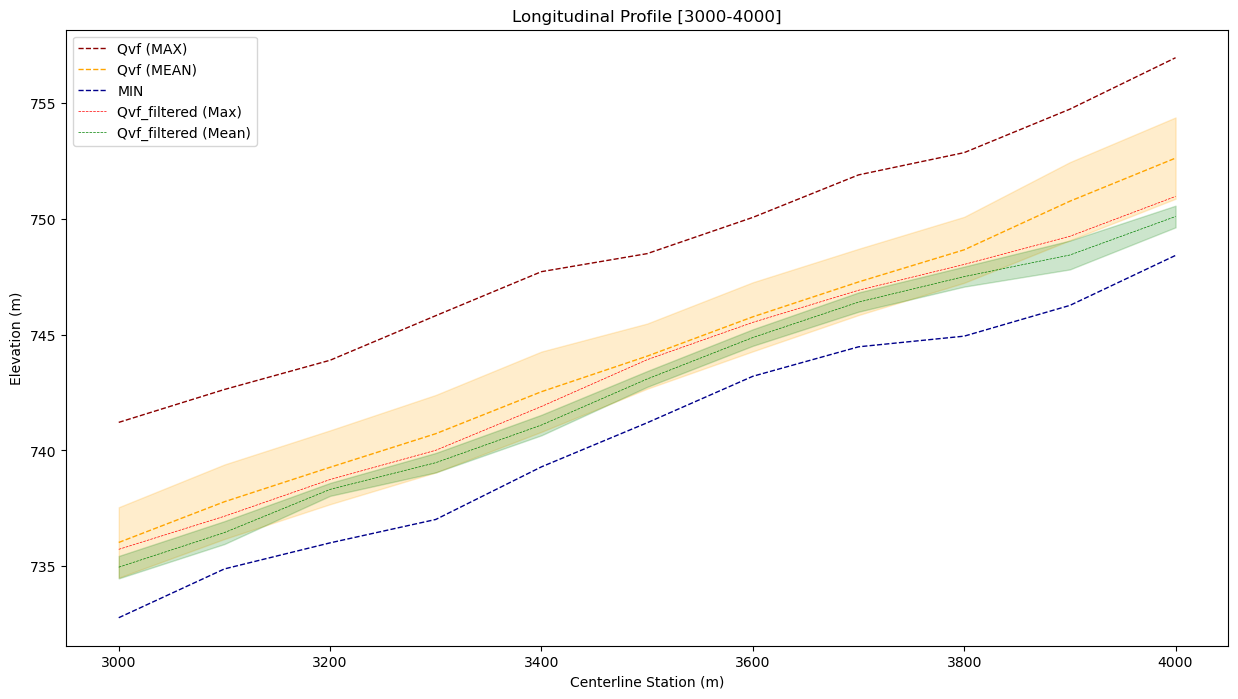

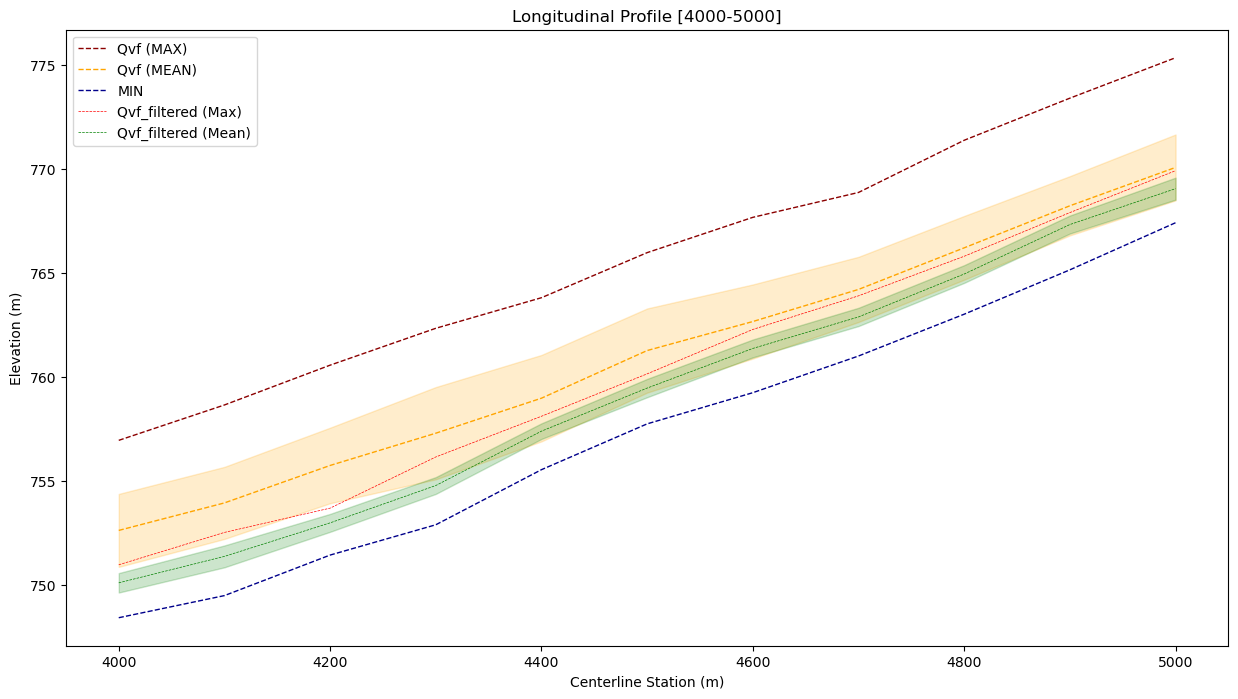

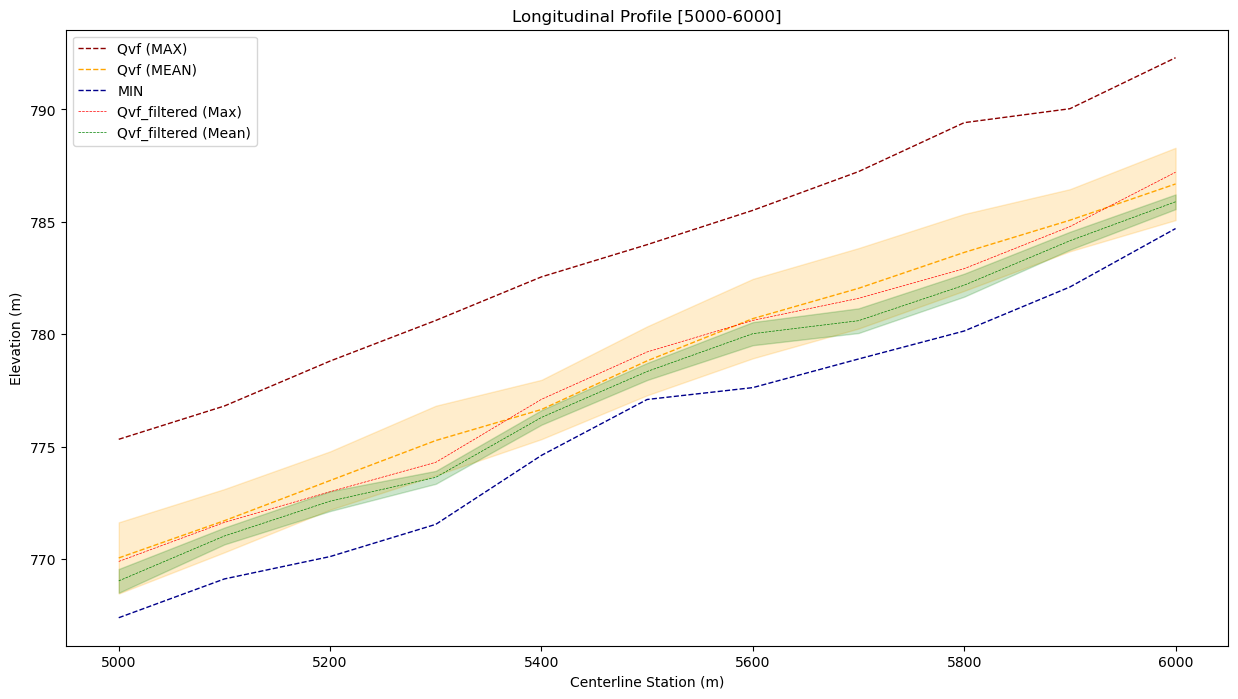

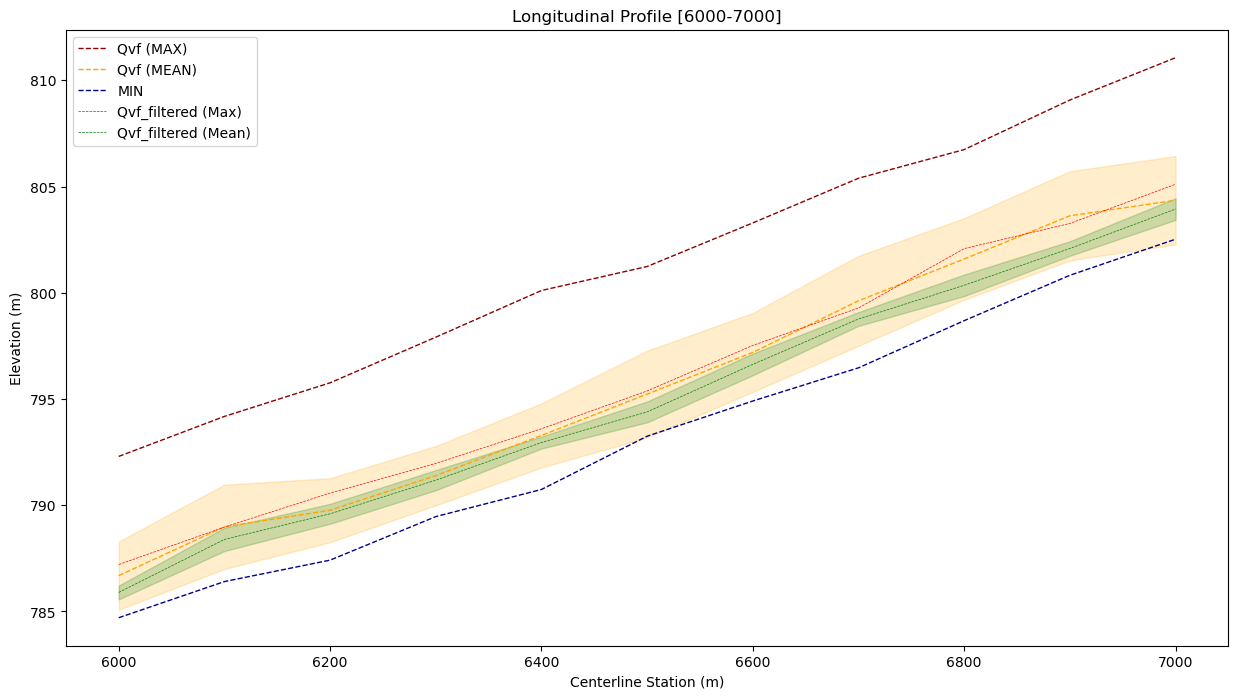

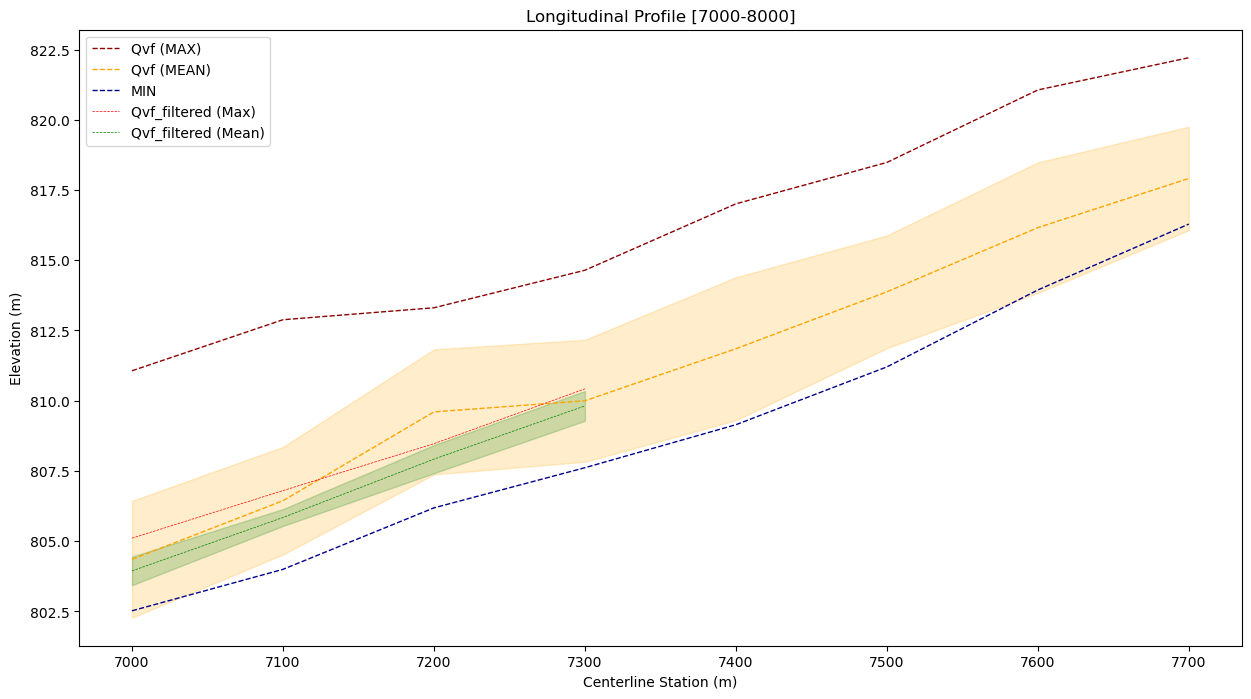

In [22]:
pf.long_plot_compare(df = df_vf_less8m,
                     df_filtered = df_vf_fp2t1,
                     vcl_stations = x,
                     elevation = z,
                     interval=1000 )

# Plot and Inspect Transect Elevation Profiles and Statistics

### Function: `transect_plot`

This function generates a transect profile, showing summary statistics (mean ± std) of transect elevation data.

>Assumes metric units

**Arguments:**
- `df` *(pd.DataFrame)*: Input data
- `vcl_stations` *(str)*: Column name for valley centerline stations
- `transect_stations` *(str)*: Column name for transect station positions
- `elevation` *(str)*: Column name for elevation values
- `transect` *(int/float)*: Transect identifier to filter
- `filtered_df` *(pd.DataFrame, optional)*: External table with mean/std values
- `aspect` *(float or str, optional)*: Aspect ratio for plot

**Returns:**
- `(fig, ax)`: Matplotlib figure and axis

>Returned Mean is for all pass data.

**Example:**
```python
transect_plot(
    df=df_vf,
    vcl_stations=x,
    transect_stations=y,
    elevation=z,
    transect=[x],
    filtered_df=None,
    aspect:None)


## Print List of Available Transects

In [23]:
df_vf_fp2t1[x].unique().tolist()

[100,
 200,
 300,
 400,
 500,
 600,
 700,
 800,
 900,
 1000,
 1100,
 1200,
 1300,
 1400,
 1500,
 1600,
 1700,
 1800,
 1900,
 2000,
 2100,
 2200,
 2300,
 2400,
 2500,
 2600,
 2700,
 2800,
 2900,
 3000,
 3100,
 3200,
 3300,
 3400,
 3500,
 3600,
 3700,
 3800,
 3900,
 4000,
 4100,
 4200,
 4300,
 4400,
 4500,
 4600,
 4700,
 4800,
 4900,
 5000,
 5100,
 5200,
 5300,
 5400,
 5500,
 5600,
 5700,
 5800,
 5900,
 6000,
 6100,
 6200,
 6300,
 6400,
 6500,
 6600,
 6700,
 6800,
 6900,
 7000,
 7100,
 7200,
 7300]

## Plot Individual Transect Profile

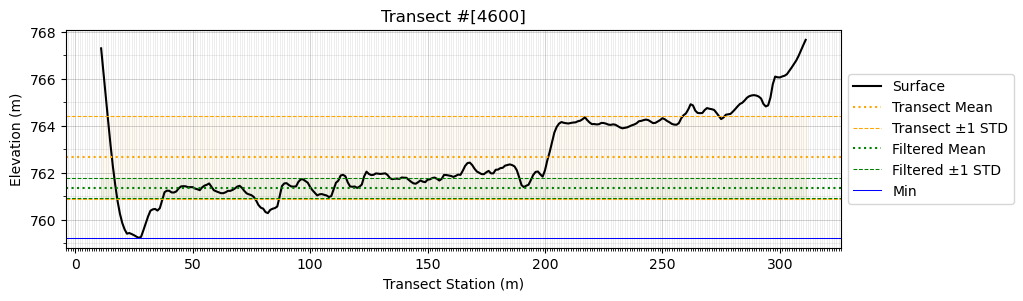

In [24]:
transects = [4600]
for transect in transects:
    pf.transect_plot(df = df_vf_less8m, 
                 vcl_stations = x, 
                 transect_stations = y, 
                 elevation =  z, 
                 transect = transects,
                 filtered_df = df_vf_fp2t1,
                 aspect = 10
                )#[0].savefig(fc_path + r'\Transect' + str(transect) + '.png')

## Plot a Few Transects 

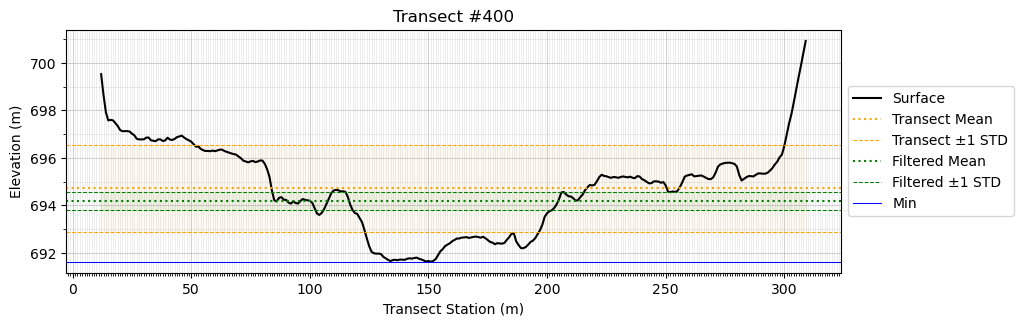

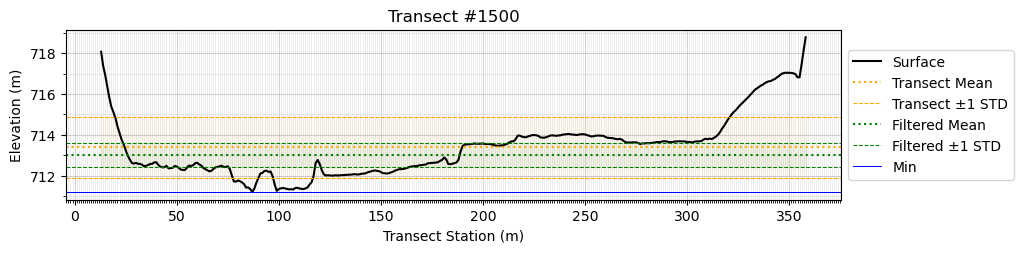

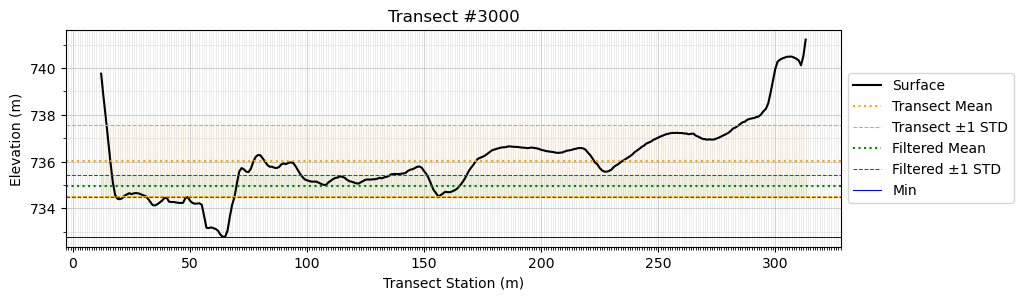

In [25]:
transects = [400, 1500, 3000]
for transect in transects:
    pf.transect_plot(df = df_vf_less8m, 
                 vcl_stations = x, 
                 transect_stations = y, 
                 elevation =  z, 
                 transect = transect,
                 filtered_df = df_vf_fp2t1,
                 aspect = 10
                )#[0].savefig(fc_path + r'\Transect' + str(transect) + '.png')

## Plot a Subset of Transects using Conditional Formatting

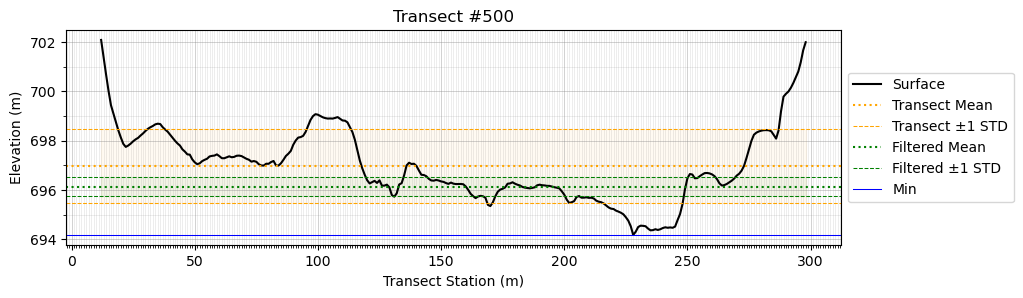

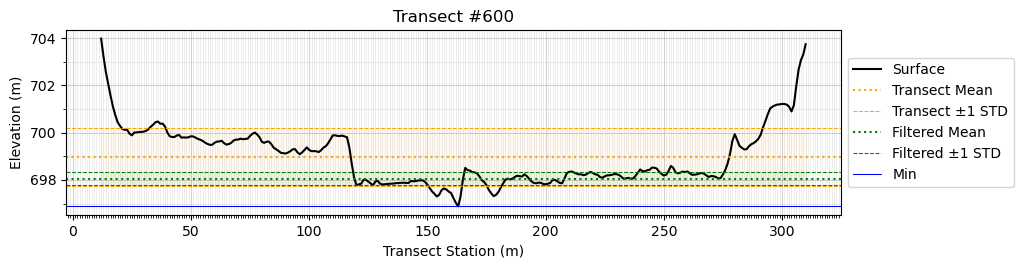

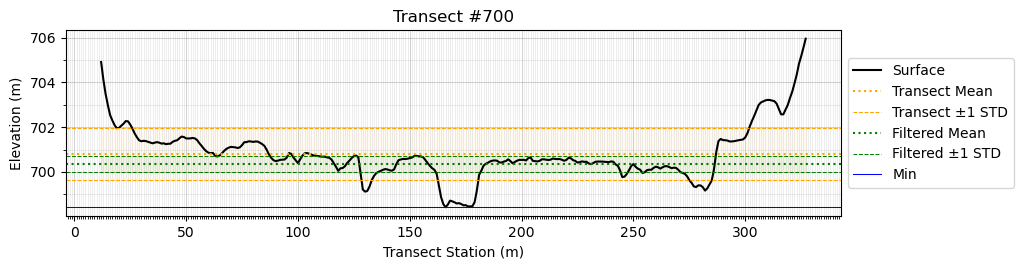

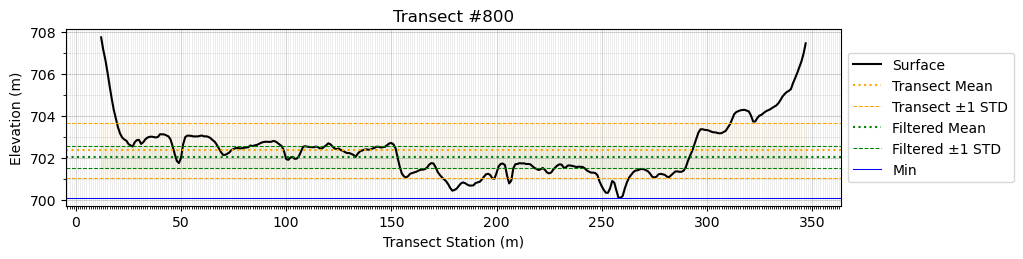

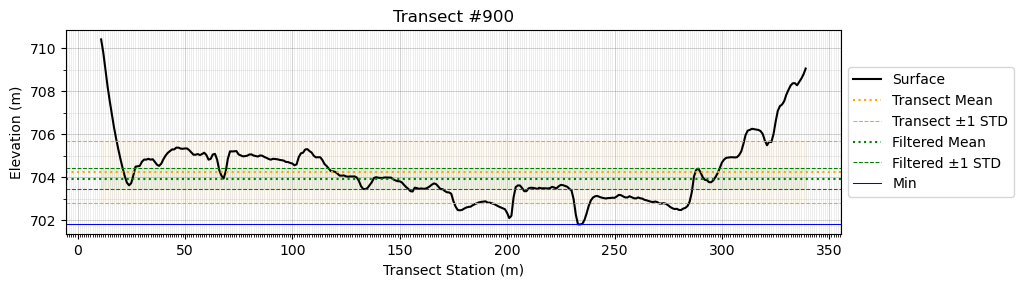

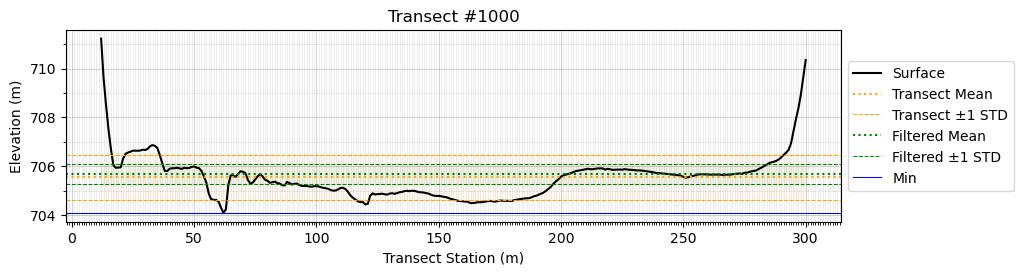

In [26]:
lower = 500
upper = 1000
transects_subset = df_vf_less8m[df_vf_less8m[x].between(lower, upper)][x].unique().tolist()
for t in transects_subset:
    pf.transect_plot(df_vf_less8m, x, y, z, t, df_vf_fp2t1, 10)#[0].savefig(fc_path + r'\Transect' + str(transect) + '.png')

## Plot All Transects

<div style="border:2px solid red; padding:10px; background-color:#ffe6e6;">
⚠️ <b>Warning:</b> Plotting a large number of transects at once can significantly slow down performance and clutter your notebook. For clarity and speed, consider limiting the number of transects you display in a single run.
</div>


In [27]:
# transects = df[x].unique().tolist()
# for t in transects:
#     Tpf.transect_plot(df_vf_less8m, x, y, z, t, None, 10)#[0].savefig(fc_path + r'\Transect' + str(transect) + '.png')

# Gather Descriptive Statistics of Transect Elevations

### Function: `describe_stats`

This function computes descriptive statistics for a grouped column.

**Arguments:**
- `df` *(pd.DataFrame)*: Input DataFrame
- `group` *(str or list)*: Column(s) to group by
- `value` *(str)*: Column to compute stats on
- `name` *(str)*: Prefix for renamed stats columns

**Returns:**
- `table` *(pd.DataFrame)*: Grouped descriptive statistics with renamed columns and IQR


**Example:**
```python
describe_stats(
    df = df_vf_filtered,
    group= x,
    value= z,
    name= "VF_Less8m")
```

<br>
<!-- Info style -->
<div style="border:2px solid #2196F3; padding:10px; background-color:#E3F2FD;">
    ℹ️ <b>Info:</b> This function can be used to used to generate multiple descriptive statistics (ds) tables to compare transect elevation values. <br>
    For example: mean of all transect stations vs mean of only floodplain stations).
</div>

In [28]:
ds_vf_fp2t1 = pf.describe_stats(df_vf_fp2t1, x, z, 'FP2T1') ###Qav includes all transect station elevations

In [29]:
ds_vf_fp2t1

,VCL_Station_Sequence,FP2T1_count,FP2T1_mean,FP2T1_std,FP2T1_min,FP2T1_25%,FP2T1_50%,FP2T1_75%,FP2T1_max,FP2T1_IQR
0,100,36.0,688.980767,0.359270,688.463745,688.719284,688.813965,689.378143,689.701294,0.658859
1,200,94.0,690.283722,0.432693,689.357300,689.999588,690.389465,690.616638,691.039246,0.617050
2,300,124.0,692.091449,0.413688,690.963928,691.812729,692.177338,692.451126,692.673462,0.638397
3,400,63.0,694.187829,0.378548,692.960632,694.034943,694.228943,694.525299,694.865967,0.490356
4,500,124.0,696.130197,0.396706,695.237488,695.782013,696.187286,696.381042,697.194580,0.599030
...,...,...,...,...,...,...,...,...,...,...
68,6900,64.0,802.084476,0.342119,801.645996,801.847336,802.027435,802.174942,803.264771,0.327606
69,7000,27.0,803.942876,0.508408,803.403503,803.566803,803.787659,804.128387,805.108643,0.561584
70,7100,59.0,805.842969,0.301424,805.034424,805.673859,805.794678,805.903778,806.801147,0.229919
71,7200,29.0,807.921305,0.501984,806.791077,807.646790,808.081604,808.309509,808.470459,0.662720


# Transect Minimum Elevation Spline Fit
### Function: `spline_fit`

This function fits a Univariate Spline to a give dataset.

**Parameters:**
- `df` *(pd.DataFrame)*: Pandas DataFrame containing the transect data.
- `x` *(str)*: Column name for VCL station values (independent variable).
- `y` *(str)*: Column name for elevation values (dependent variable).
- `k` *(int, 1 = linear, up to 5)*: Degree of the spline polynomial.
- `s` *(int/float)*: Smoothing factor (None for exact fit, >0 for smoothing).



**Returns:**
- `model`: Fitted UnivariateSpline object.
- `figure`: Matplotlib figure showing the spline fit.
- `table`: Pandas DataFrame of fitted values (x, y).

**Example:**

```python
fit_vf_less8m_model, fit_vf_less8m_table, fit_vf_less8m_figs = spline_fit(
    df=ds_vf_less8m,
    x = x,
    y='VF_Less8m_min',
    k=3,
    s=5)
```
---

## Spline Fit Guidance

When fitting transect elevation data with `UnivariateSpline`, two parameters control the model:  
the **polynomial order (`k`)** and the **smoothing factor (`s`)**.

---

### Polynomial Order (`k`)
- **Linear (k=1)** → Use for monotonic transects (smooth slope, no curvature).  
- **Quadratic/Cubic (k=2–3)** → Use for gentle curvature or one inflection point.  
- **Quartic/Quintic (k=4–5)** → Use only for complex undulations with many data points.  
⚠️ Higher orders risk overfitting.

---

### Smoothing Factor (`s`)

The smoothing factor controls how closely the spline follows the data.

- **`s=0` → Exact interpolation**  
  - Places a knot at every data point.  
  - The spline passes through all points exactly.  
  - Best for clean data with little noise.  
  - Risk: overfitting if measurements are noisy.

- **`s=None` → Automatic smoothing**  
  - SciPy chooses a smoothing level based on the data size and variance.  
  - The spline does *not* necessarily pass through every point.  
  - Produces a smoother curve without manual tuning.
  - Useful to evaluate complexity of the slope based on number of knots.

- **`s>0` (user‑defined)**  
  - You control the amount of smoothing.  
  - Larger `s` → smoother curve, LESS KNOTS, less fidelity to individual points.  
  - Smaller `s` → closer fit, MORE KNOTS, more detail preserved.  
  - Scale of `s` depends on your dataset (number of points, variance, units). Explore values between 0 and the data length (total number of transects)
  - Try dividing `s` in half to in crease number of knots.
  - There are no universal ranges — always tune interactively.

---

### Best Practice
- Begin with **low order (`k=1–3`)** and **model fit (`s=None`)**.
- Visually inspect the difference between data values (solid black), model fit (dashed red), and linear fit (solid orange).
- Increase `k` only if the transect shows clear curvature.  
- Increase `s` only if the data is noisy.
- Always visualize the fit before interpreting results.

<!-- Warning style -->
<div style="border:2px solid #FF9800; padding:10px; background-color:#FFF3E0;">
    ⚠️ <b>Caution:</b> Knot locations are not an indicator of knickpoints (geomorphic controls).
</div>

<br>
<!-- Info style -->
<div style="border:2px solid #2196F3; padding:10px; background-color:#E3F2FD;">
ℹ️ <b>Note:</b>Since we have bathymetric LiDAR data we can reasomnably assume that the transect minimum is a good approximation with little noise. In that case we could use k=1 and s=0 to fit a linear trealine between each 100m valley centerline station. However, we typically apply a little smoothing to clean the profile. 
</div>

**** SPLINE FIT RESULTS ****
-------------------------
Data Length = 73
Polynomial Order = 3
Smoothing Factor = 2
-------------------------
Rise = 120.83 m, Run = 7200.00 m
Generic Slope = 1.68%
-------------------------
Average Slope = 1.68%
Residual Sum of Squares = 2.0001
Residual Variance = 0.0274


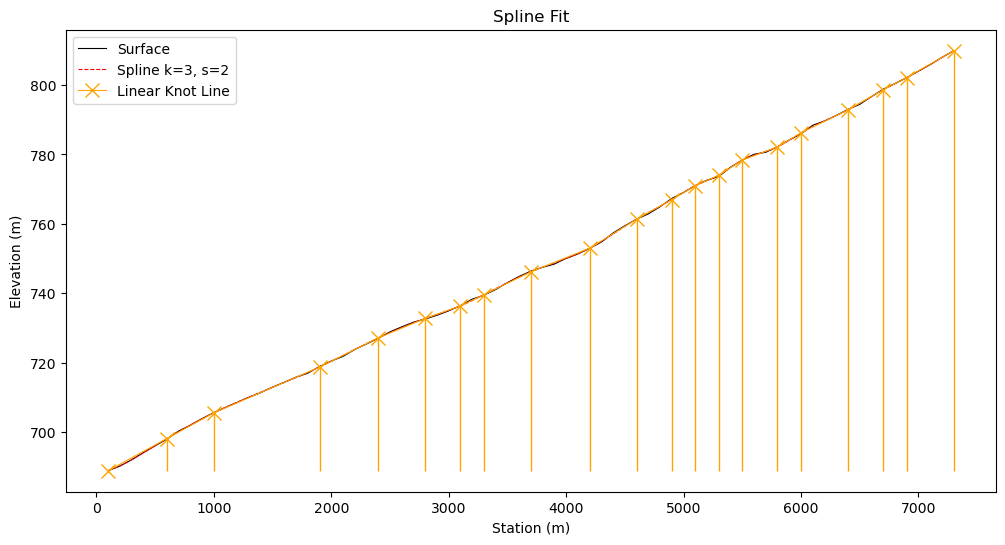

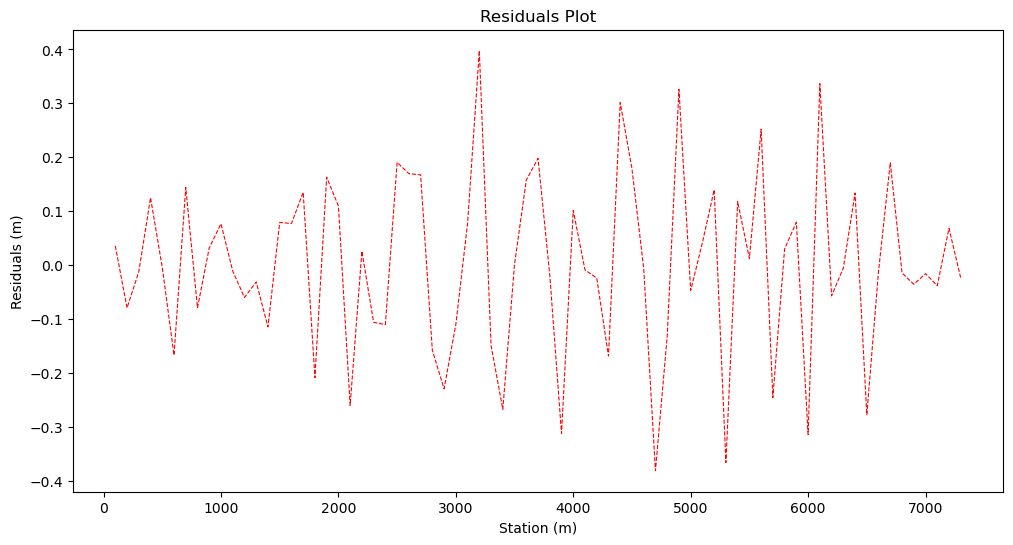

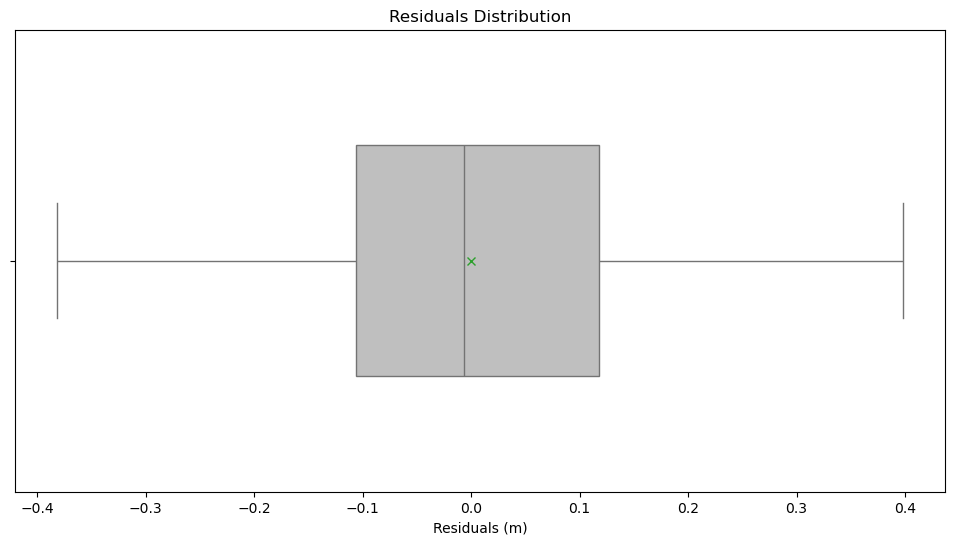

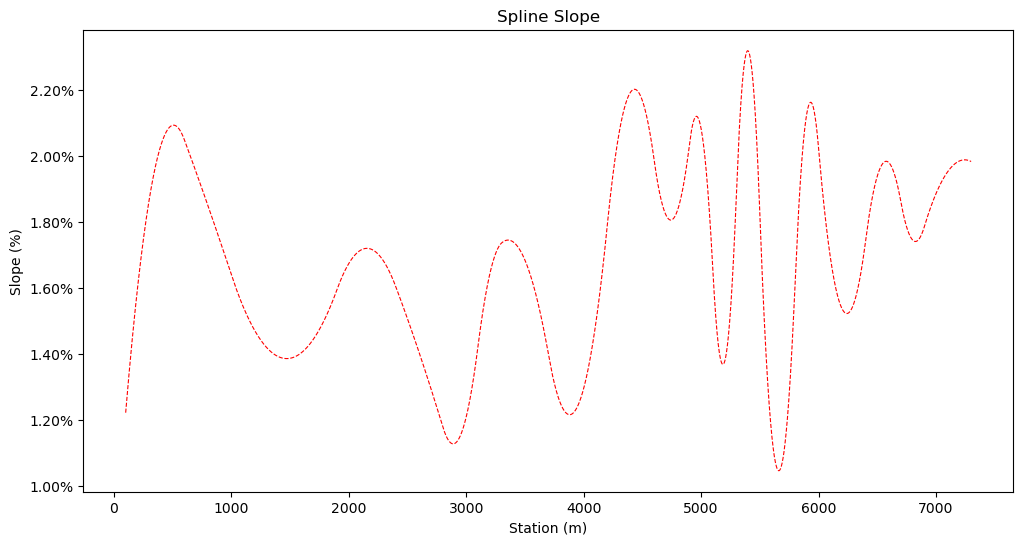

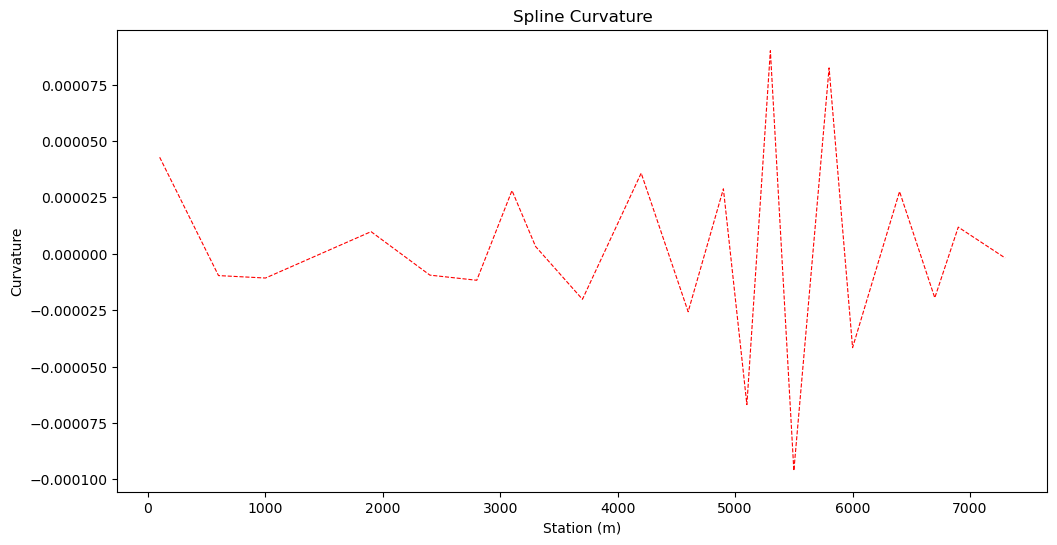

In [37]:
fit_vf_fp2t1_model, fit_vf_fp2t1_table, fit_vf_fp2t1_figs = pf.spline_fit(ds_vf_fp2t1, x, 'FP2T1_mean', k=3, s=2)

## Inspect GGL Table

In [38]:
fit_vf_fp2t1_table

,VCL_Station_Sequence,Fit_FP2T1_mean_poly3_s2
0,100,688.945135
1,101,688.957374
2,102,688.969654
3,103,688.981978
4,104,688.994344
...,...,...
7195,7295,809.740943
7196,7296,809.760784
7197,7297,809.780623
7198,7298,809.800460


In [39]:
## Calculate Model Value for any Station 'x'

In [40]:
fit_vf_fp2t1_model([10, 100, 1000])

array([688.0315642 , 688.94513518, 705.60751293])

## Merge GGL Table with Valley DataFrames

In [41]:
rem_vf = pd.merge(df_vf, fit_vf_fp2t1_table, on=x)
rem_vf_less8m = pd.merge(df_vf_less8m, fit_vf_fp2t1_table, on=x)
rem_vf_fp2t2 = pd.merge(df_vf_fp2t1, fit_vf_fp2t1_table, on=x)

## Calculate Relative Elevation

In [42]:
rem_vf['RE_Fit_FP2T1_mean_poly3_s2'] = rem_vf[z] - rem_vf['Fit_FP2T1_mean_poly3_s2']
rem_vf_less8m['RE_Fit_FP2T1_mean_poly3_s2'] = rem_vf_less8m[z]-rem_vf_less8m['Fit_FP2T1_mean_poly3_s2']
rem_vf_fp2t2['RE_Fit_FP2T1_mean_poly3_s2'] = rem_vf_fp2t2[z]-rem_vf_fp2t2['Fit_FP2T1_mean_poly3_s2']

# Plot Boxplot with Summary Statistics
### Function: `boxplot`
This function creates a horizontal boxplot with descriptive statistics for a specified field, displaying distribution characteristics including outliers and mean values.
>Assumes metric units

**Parameters:**
- `df` (pd.DataFrame): Input data
- `Field` (str): Column name for the field to plot
- `Title` (str, optional): Plot title

**Returns:**
- None (displays plot and prints statistics)

**Example:**
```python
boxplot(
    df=df_vf,
    Field='rel_elev_m',
    Title="Relative Elevation Distribution"
)

count    22040.000
mean         1.609
std          2.901
min         -2.599
25%         -0.193
50%          0.746
75%          2.469
max         20.674
Name: RE_Fit_FP2T1_mean_poly3_s2, dtype: float64


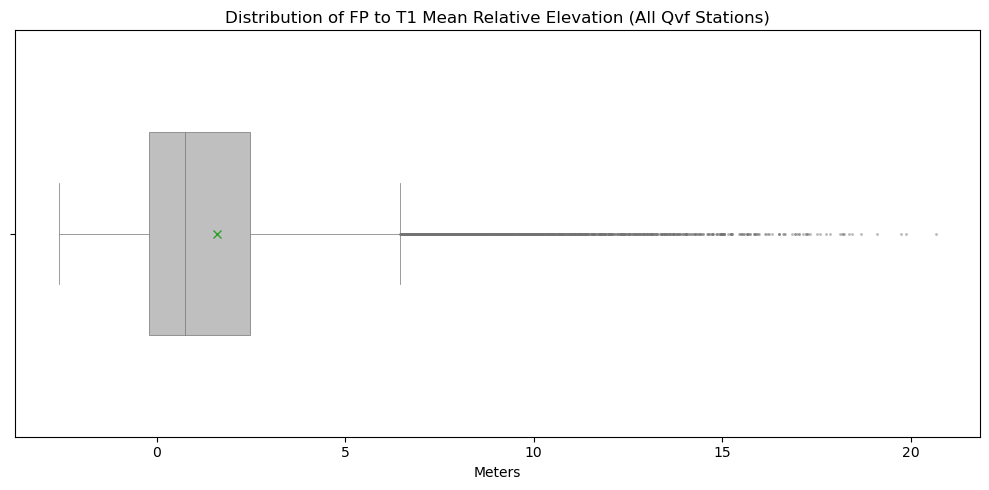

count    20419.000
mean         0.975
std          1.749
min         -2.599
25%         -0.257
50%          0.576
75%          1.904
max          7.613
Name: RE_Fit_FP2T1_mean_poly3_s2, dtype: float64


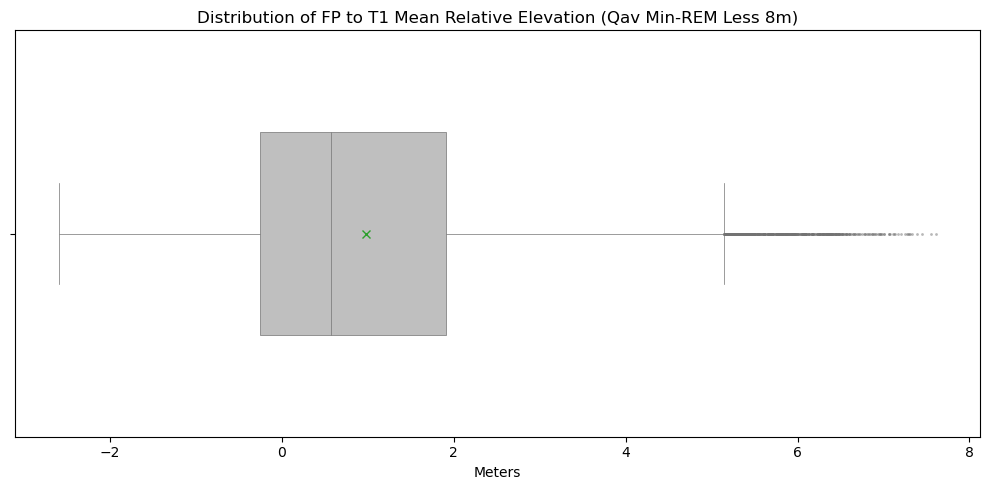

count    8834.000
mean        0.010
std         0.455
min        -1.421
25%        -0.342
50%         0.012
75%         0.351
max         1.713
Name: RE_Fit_FP2T1_mean_poly3_s2, dtype: float64


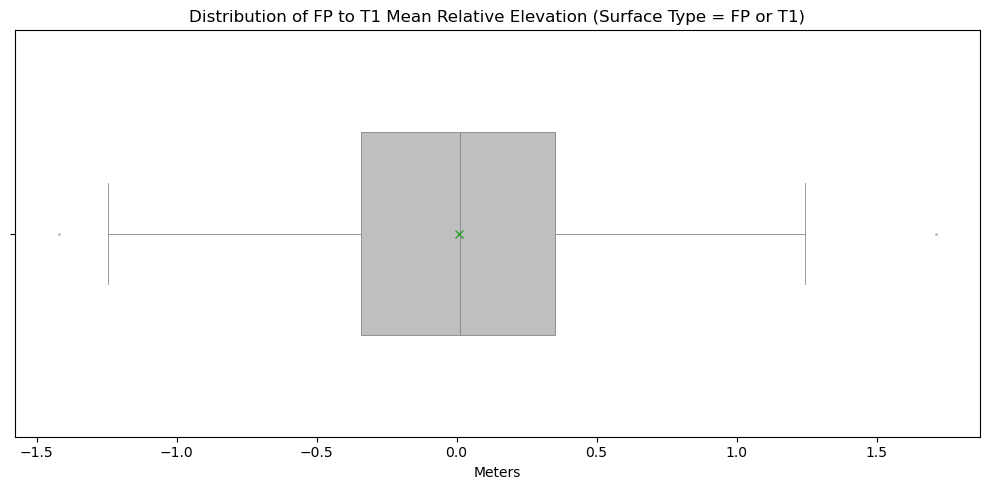

In [43]:
pf.boxplot(rem_vf, 'RE_Fit_FP2T1_mean_poly3_s2', "Distribution of FP to T1 Mean Relative Elevation (All Qvf Stations)")
pf.boxplot(rem_vf_less8m, 'RE_Fit_FP2T1_mean_poly3_s2', "Distribution of FP to T1 Mean Relative Elevation (Qav Min-REM Less 8m)")
pf.boxplot(rem_vf_fp2t2, 'RE_Fit_FP2T1_mean_poly3_s2', "Distribution of FP to T1 Mean Relative Elevation (Surface Type = FP or T1)")

# Plot Histogram with Distribution Statistics
### Function: `histplot`
This function creates a histogram with kernel density estimation (KDE) overlay, displaying mean and standard deviation boundaries with statistical shading.
>Uses 0.2 meter bin width for metric data

**Parameters:**
- `df` (pd.DataFrame): Input data
- `Field` (str): Column name for the field to plot
- `Title` (str, optional): Plot title
- `x_Label` (str, optional): Custom x-axis label (defaults to field name)

**Returns:**
- None (displays plot)

**Example:**
```python
histplot(
    df=df_vf,
    Field='rel_elev_m',
    Title="Relative Elevation Distribution",
    x_Label="Elevation (meters)"
)

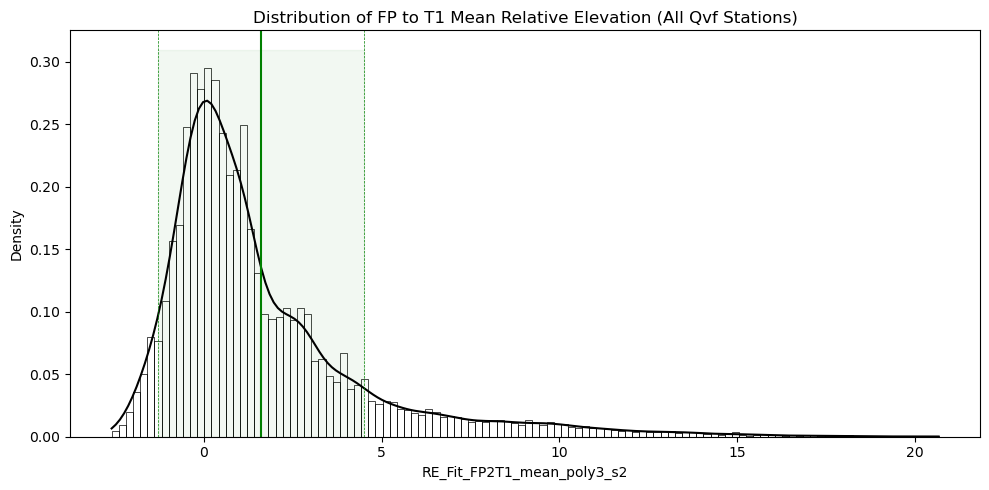

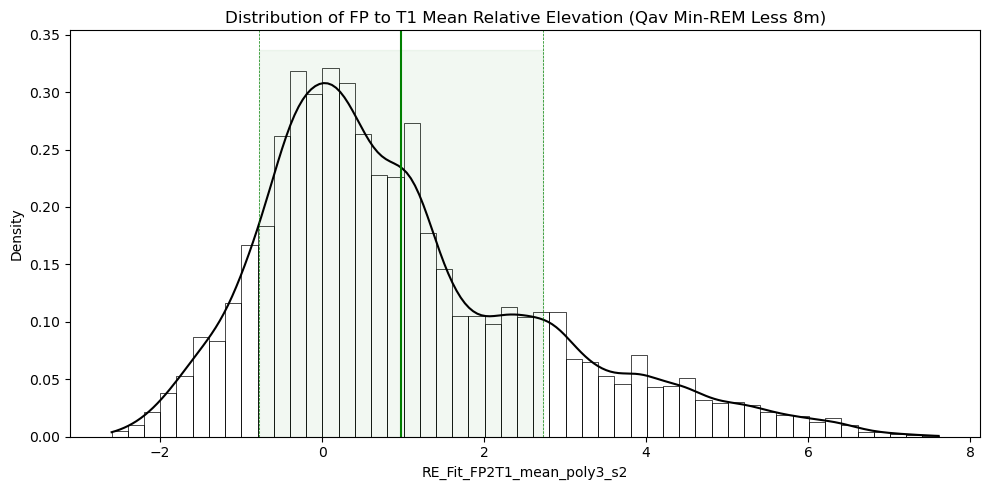

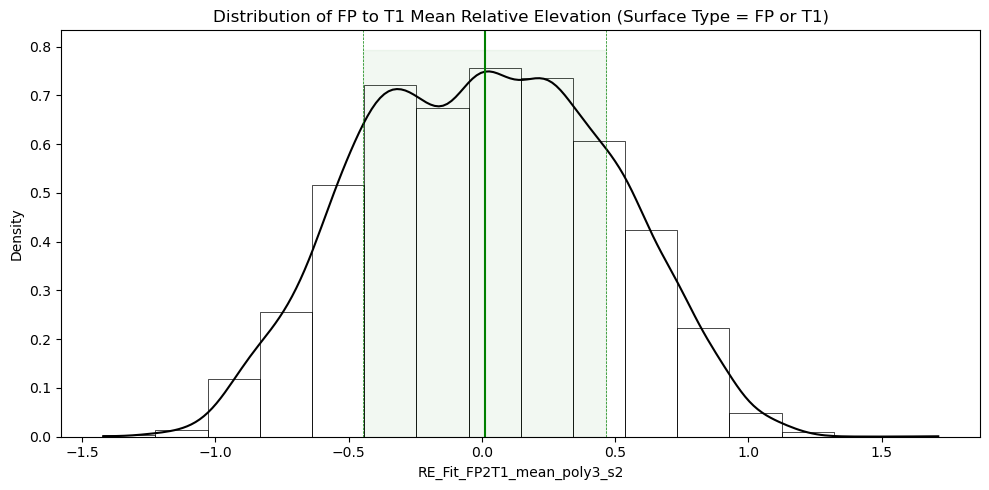

In [44]:
pf.histplot(rem_vf, 'RE_Fit_FP2T1_mean_poly3_s2', "Distribution of FP to T1 Mean Relative Elevation (All Qvf Stations)")
pf.histplot(rem_vf_less8m, 'RE_Fit_FP2T1_mean_poly3_s2', "Distribution of FP to T1 Mean Relative Elevation (Qav Min-REM Less 8m)")
pf.histplot(rem_vf_fp2t2, 'RE_Fit_FP2T1_mean_poly3_s2', "Distribution of FP to T1 Mean Relative Elevation (Surface Type = FP or T1)")

# Plot Comparative Histogram with Two Datasets
### Function: `histplot_compare`
This function creates a histogram with kernel density estimation (KDE) for a primary dataset, with optional overlay of statistical markers from a filtered/comparison dataset to visualize distributional differences.
>Uses 0.2 meter bin width for metric data

**Parameters:**
- `df` (pd.DataFrame): Primary input data for histogram
- `Field` (str): Column name for the field to plot
- `Title` (str, optional): Plot title
- `x_Label` (str, optional): Custom x-axis label (defaults to "Distribution of {Field}")
- `filtered_df` (pd.DataFrame, optional): Comparison dataset for statistical overlay

**Returns:**
- None (displays plot)

**Example:**
```python
histplot_compare(
    df=df_all_points,
    Field='rel_elev_m',
    Title="Valley Floor vs All Points Elevation Distribution",
    x_Label="Relative Elevation (meters)",
    filtered_df=df_valley_floor
)

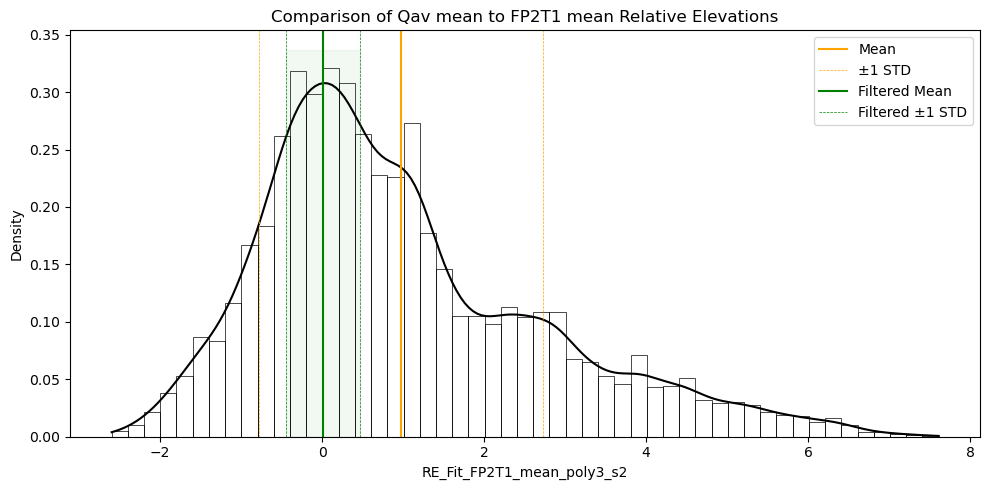

In [45]:
pf.histplot_compare(rem_vf_less8m, 'RE_Fit_FP2T1_mean_poly3_s2', "Comparison of Qav mean to FP2T1 mean Relative Elevations", filtered_df=rem_vf_fp2t2)
# pf.histplot(rem_vf_fp2t2, 'RE_Fit_FP2T1_mean_poly3_s2', "Distribution of FP to T1 Mean Relative Elevation (Surface Type = FP or T1)")

# Export Model Fit Table as CSV and Join to Transect Stations

### Function: `csv_join`

This function saves a Pandas DataFrame as a CSV file and optionally joins its columns to a GIS feature class based on a common ID field.

**Parameters:**
- `df` *(pd.DataFrame)*: Pandas DataFrame containing the data to export.
- `dir_path` *(str)*: Directory path where the CSV will be saved.
- `fc` *(str)*: Feature class (layer) to join the DataFrame to.
- `join_field` *(str)*: Field name used as the join key.
- `do_join` *(bool, default=True)*: If True, append the CSV columns to the feature class.


**Returns:**
- `output`: csv of the input DataFrame.


**Example:**
```python
csv_join(
    df=fit_vf_less8m_table,
    dir_path=fc_path,
    fc=fc_name,
    join_field=x,
    do_join=True)
```

<!-- Caution style -->
<div style="border:2px solid #FF9800; padding:10px; background-color:#FFF3E0;">
    ⚠️ <b>Caution:</b> Saving a CSV will overwrite any existing file with the same name in <code>dir_path</code>. 
    Use unique filenames or check before running to avoid losing data.
</div>
<br>
<!-- Caution style -->
<div style="border:2px solid #FF9800; padding:10px; background-color:#FFF3E0;">
    ⚠️ <b>Caution:</b> Duplicate column names will be ignored when joining columns to GIS feature class.
</div>

In [128]:
# pf.csv_join(fit_vf_fp2t1_table, fc_path, fc_name, x, do_join=True)

'T:\\FS\\BusOps\\EnterpriseProgram\\Program\\AquaticRestoration\\Projects\\Washington\\Teanaway\\Teanaway_Tutorial_Helstab\\Fit_FP2T1_mean_poly3_s2_12JAN2026.csv'

# Create Relative Elevation Model (REM) from Transect Stations

### Function: `create_rem_from_tin`

This function builds a TIN surface from transect station points, converts the TIN to a raster, subtracts the rasterized surface from an existing LiDAR DEM, and adds the resulting Relative Elevation Model (REM) to the active ArcGIS Pro map. Optionally, a polygon mask can be provided to clip the outputs to a project boundary.

**Parameters:**
- `fc_name` *(str)*: Path to the transect station feature class.
- `height_field` *(str)*: Field name used as elevation (e.g., column two from `fit_vf_less8m_table`).
- `lidar_dem` *(str)*: Path to the existing LiDAR DEM raster.
- `out_tin` *(str)*: Name for the output TIN dataset.
- `out_raster` *(str)*: Name for the output raster converted from the TIN.
- `out_rem` *(str)*: Name for the output Relative Elevation Model raster.
- `mask` *(str, optional)*: Layer Name or Path to a polygon feature class or shapefile used to clip the raster outputs. Default is `None`.

**Returns:**
- `out_rem`: The REM raster dataset, also added to the active ArcGIS Pro map contents.

**Example:**
```python
create_rem_from_tin(
    fc_name=fc_name,
    height_field="Splint Fit Column Name",
    lidar_dem="DEM layer",
    out_tin="tin",
    out_raster="tin_raster",
    out_rem="tin_rem",
    mask="Boundary layer")
```

<!-- Caution style -->
<div style="border:2px solid #FF9800; padding:10px; background-color:#FFF3E0;"> ⚠️ <b>Caution:</b> Ensure <code>height_field</code> exists in the input feature class. If the field name is incorrect, the TIN creation will fail. </div>
<br>
<!-- Caution style --> 
<div style="border:2px solid #FF9800; padding:10px; background-color:#FFF3E0;"> ⚠️ <b>Caution:</b> The REM raster will overwrite any existing file at <code>out_rem</code>. Use unique filenames or check before running to avoid losing data. </div>
<br> 
<!-- Caution style --> <div style="border:2px solid #FF9800; padding:10px; background-color:#FFF3E0;"> ⚠️ <b>Caution:</b> If a <code>mask</code> is provided, outputs will be clipped to that polygon. Ensure the mask is in the same spatial reference as the input data to avoid misalignment. </div>


In [46]:
# pf.create_rem_from_tin(
#     fc_name=fc_name,
#     height_field=fit_vf_fp2t1_table.columns[1] ,
#     lidar_dem="MFT_LiDAR_Bathy_Void_Interpolated_FIPS_4602_m",
#     gdb= fc_gdb ,
#     mask="MF_Teanaway_VBP")

TIN created:
T:\FS\BusOps\EnterpriseProgram\Program\AquaticRestoration\Projects\Washington\Teanaway\Teanaway_Tutorial_Helstab\Teanaway_Tutorial_Helstab.gdb/tin_Fit_FP2T1_mean_poly3_s2
--------------------------------------------------
TIN converted to raster with cell size 0.9143684770025406:
T:\FS\BusOps\EnterpriseProgram\Program\AquaticRestoration\Projects\Washington\Teanaway\Teanaway_Tutorial_Helstab\Teanaway_Tutorial_Helstab.gdb/tin_raster_Fit_FP2T1_mean_poly3_s2
--------------------------------------------------
Relative Elevation Model created:
T:\FS\BusOps\EnterpriseProgram\Program\AquaticRestoration\Projects\Washington\Teanaway\Teanaway_Tutorial_Helstab\Teanaway_Tutorial_Helstab.gdb/tin_rem_Fit_FP2T1_mean_poly3_s2
--------------------------------------------------
Mask enabled:
MF_Teanaway_VBP
--------------------------------------------------
TIN Raster masked to MF_Teanaway_VBP:
T:\FS\BusOps\EnterpriseProgram\Program\AquaticRestoration\Projects\Washington\Teanaway\Teanaway_Tu